# Módulo III: Sincronización y telemetría

Ahora que hemos podido demodular la señal y decodificar una primera imagen veremos como mejorar varios aspectos. En particular en este módulo veremos como sincronizar y calibrar la imagen a partir de los datos de telemetría.

`Grupo`:D1

`Estudiantes`:Agustin Ferreira - Luca Guarino - Juan Igancio Sorondo

## Funciones auxiliares
Se ponen a disposición las siguientes funciones que pueden ser de utilidad:

In [ ]:
from scipy.io.wavfile import read
from PIL import Image
from matplotlib.pyplot import imshow
from matplotlib import pyplot as plt
import numpy as np
def visualizar_imagen(matriz_APT):
  img = Image.fromarray(matriz_APT)
  if img.mode != 'RGB':
      img = img.convert('RGB')
  plt.figure()
  plt.rcParams["figure.figsize"] = (14,14)
  plt.axis('off')
  plt.imshow(img,interpolation='none')

def guardar_imagen(matriz_APT, filename):
  img = Image.fromarray(matriz_APT)
  if img.mode != 'RGB':
      img = img.convert('RGB')
  img.save(filename)

def visualizar_histograma(x):
  plt.figure(figsize=(14,7))
  plt.hist(x,range(255))
  plt.ylabel('Frecuencia')
  plt.xlabel('Nivel de gris ( Blanco = 255, Negro = 0)')
  plt.title('Histograma')
  plt.show()


Para este módulo Ud. cuenta con una señal APT ya demodulada en 1D que se encuentra en la carpeta grabaciones del curso.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving apt_demod.npy to apt_demod.npy


Para saber cuantas lineas hay en nuestra señal es necesario saber cuantos segundos dura esta. Por lo tanto, dividimos el largo de la señal entre la tasa de muestreo

In [ ]:
# Levantar datos
fs = 4160
filename =  'apt_demod.npy'
apt = np.load(filename)
print(len(apt)/fs)

747.0


Como la señal dura 747 segundos, y cada linea se envia en 0.5 segundo solo basta con dividir entre esa cantidad, o multiplicar por 2, que es lo mismo

Calcular la cantidad de filas que tiene la señal, y transformar la señal 1D en una 2D. Luego visualizarla utilizando la función proporcionada "visualizar_imagen".

Recomendación: Durante lo largo del notebook, va a encontrar que hay momentos que debe trabajar con la señal en 1D, y en otro en 2D. Recomendamos implementar dos funciones, APT_a_2D que tome la señal en 1D, la cantidad de columnas y la cantidad de filas, y la transforme en 2D. De forma analoga, implementar APT_a_1D que hago lo inverso.

255.0
0.0


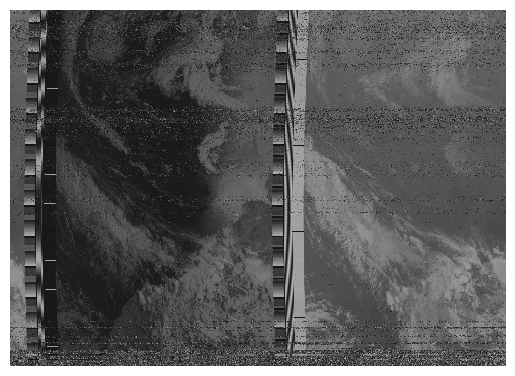

In [ ]:
# Reshape
rshapt = np.reshape(apt, ( 747*2,2080))            #) Para saber las cantidad de lineas divido el largo de nuestra data entre 4160 Hz, que es la tasa de muestreo despues de resamplear y multiplico x2 ya que cada linea se manda en 0.5 s.

print(np.amax(rshapt))
print(np.amin(rshapt))                             #) Corroboramos el minimo y el maximo. No hace falta normalizar

visualizar_imagen(rshapt)

## PARTE 1: Sincronización

Lo primero que se puede apreciar es que la imagen no comienza con uno de los cuadros de sincronización como estaba definido en el formato APT. En qué columna comience la imagen depende del momento en que se da inicio a la grabación, por lo cual es necesario corregir este aspecto.

### Ejercicio 1:
Piense en una forma de que la primera linea comience con la sincronización e implementelo. Visualize la imagen resultante


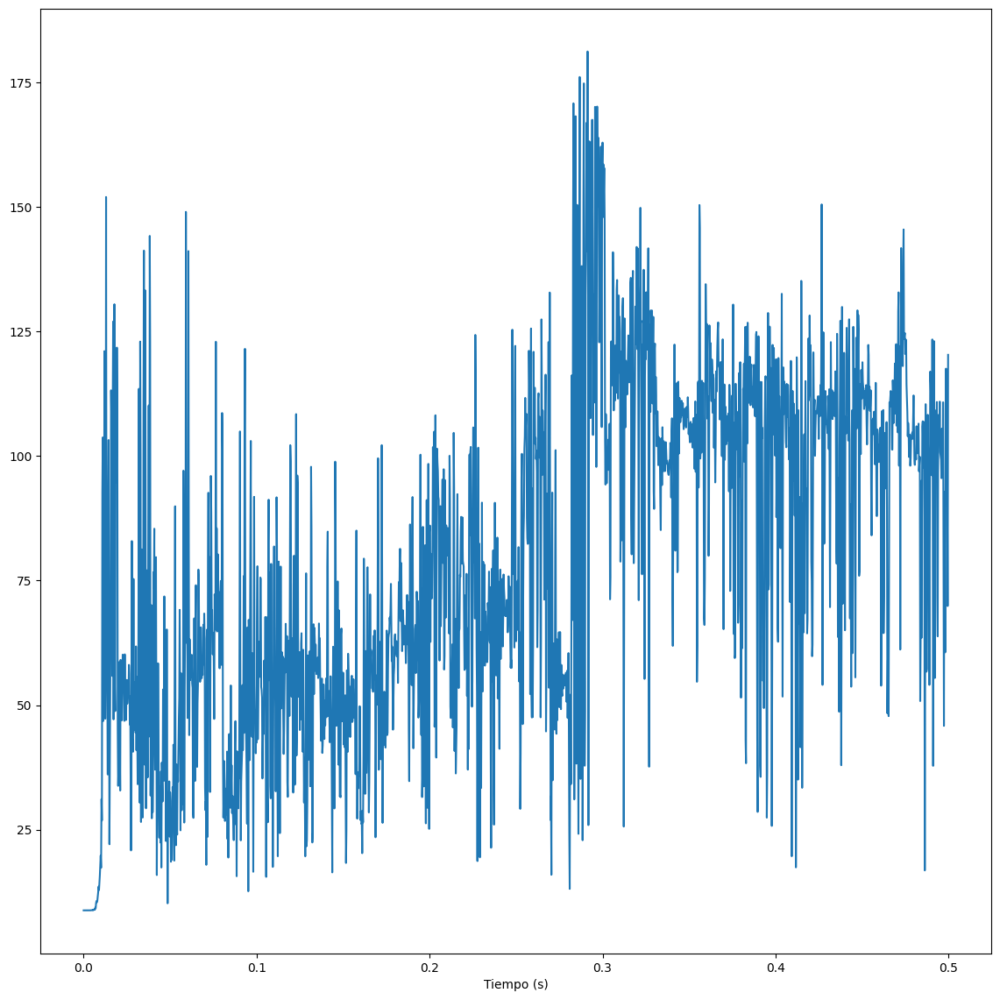

In [ ]:
t = np.linspace(0,len(apt)/4160,len(apt))  #) Utilizando lo aprendido en taller 1
plt.figure()
plt.plot(t[0:2080*1],apt[0:2080*1])
plt.xlabel('Tiempo (s)')
plt.savefig("grafica.png", dpi=150)
plt.show()


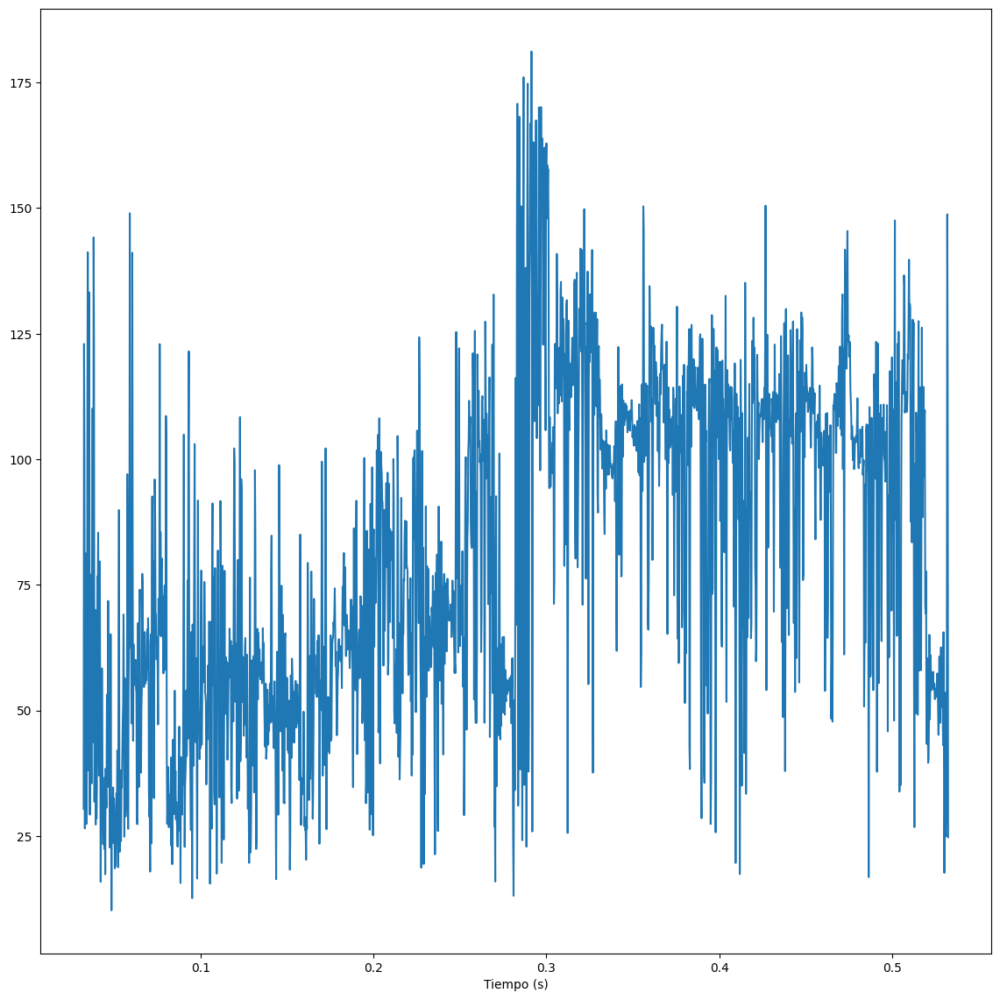

In [ ]:
plt.figure()
plt.plot(t[135:2080+135],apt[135:2080+135])           #) Calculamos a ojo
plt.xlabel('Tiempo (s)')
plt.savefig("grafica.png", dpi=150)
plt.show()


Pudimos notar que estaba corrido un poco hacia la derecha,

In [ ]:
print(fs)

4160


3105440


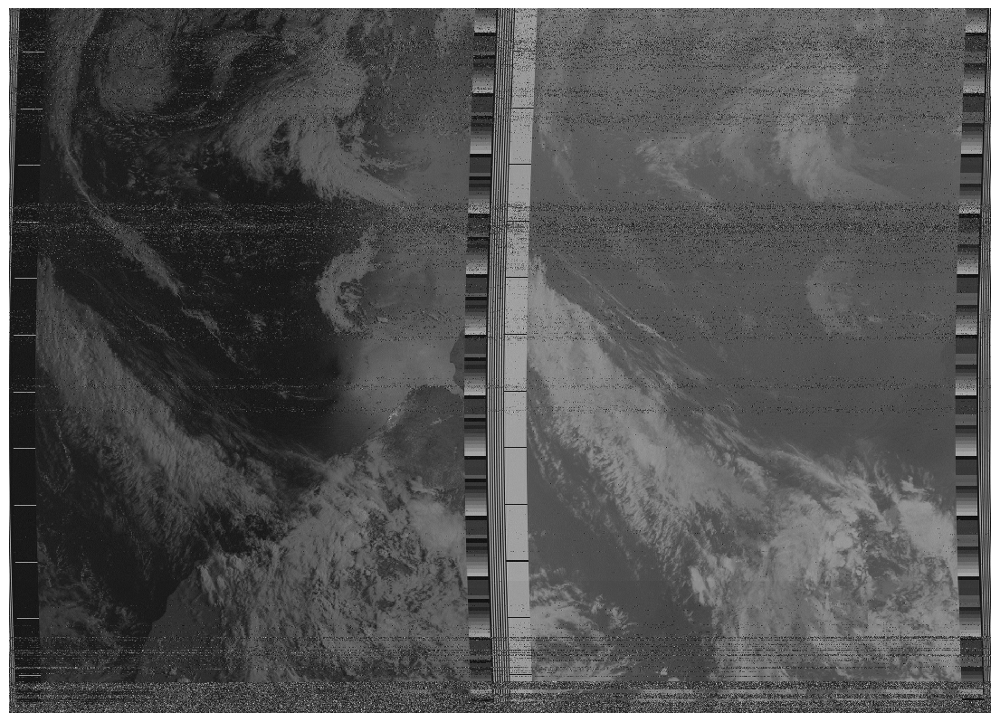

In [ ]:
nwapt=apt[135:(2080*1493)+135]           #)Tomamos las muestras a ojo viendo que el sync empezara donde deberia
print(len(nwapt))
rshapt = np.reshape(nwapt, ( 1493,2080))

visualizar_imagen(rshapt)



Aunque haya alineado la imagen con un campo de sincronización, debería observar cierta “curvatura” en la imagen, este efecto lo puede observar mejor descargando la imagen generada y abriéndola con un visor de imágenes en su PC.

La explicación para este fenómeno es que las líneas de video APT no duran exactamente $0.5~s$ como asumimos hasta ahora, sino que la duración de cada línea de video se ve afectada por el llamado efecto Doppler (ver https://es.wikipedia.org/wiki/Efecto_Doppler).

Si una fuente electromagnética se mueve en relación con un observador, hay un cambio en la frecuencia observada. Si la fuente se aleja del observador, la frecuencia observada parecerá disminuir.  Note que los satélites NOAA se mueven a una velocidad de más de $26000~km.h^{-1}$ por lo que el efecto no es despreciable.

La velocidad relativa respecto al obervador en la tierra hace que se produzca un pequeño desplazamiento en frecuencia de la subportadora de 2400 Hz que transmite el satélite. Si esto no es detectado y corregido en la demodulación, cada línea de video se adelantará o atrasará en el tiempo respecto a los $0.5~s$ en transmisión.

Si bien puede ser un error chico en cada línea de video, los errores de sincronización se van acumulando en el tiempo, lo cual produce el efecto que se puede ver en la imagen. Note que al principio entran cada vez más píxeles por línea, hasta que llega un punto en que esto se compensa, y a partir de allí aparecen cada vez más menos píxeles por línea.

Para corregir tanto el efecto Doppler como la alineación de la imagen nos ayudaremos de los campos de sincronización que se especifican en la siguiente figura:



> ![sync](https://iie.fing.edu.uy/~gbelcredi/tallerineImSat/fig/apt_sync.png)
>
>Referencia: [NOAA KLM User's Guide](http://webapp1.dlib.indiana.edu/virtual_disk_library/index.cgi/2790181/FID1497/klm/html/c4/sec4-2.htm#t422-1)


Para lo que sigue se provee la función ```obtener_muestras_comienzo_sync(signal, sync)``` que devuelve, a partir de una señal APT y una señal de sinconización, los indices de la señal APT donde comienza un patrón de sincronización.

Esta funcion recorre la el vector "signal" y busca el patrón "sync". Para esto se van tomando de a pedacitos de la señal "signal", del mismo largo que el "sync", y se mide la similaridad con "sync". La similaridad entre dos vectores se realiza matematicamente como la correlación cruzada entre estas. Puede obtener una idea intuitiva de la correlación cruzada entre señales con el ejemplo de este video: https://www.youtube.com/watch?v=cuD-LXic2cE

In [ ]:
def obtener_muestras_comienzo_sync(signal, sync):
    """!@brief Devuelve los indices de comienzo del cuadro de sincronización de una señal APT.
    @param signal Señal APT
    @param sync Vector de sincronización (SyncA o SyncB)
    @result peaks Indices de sincronización.
    """
    # list of maximum correlations found: (index, value)
    peaks_corr = [(0, 0)]

    # minimum distance between peaks
    mindistance = 2000

    # need to shift the values down to get meaningful correlation values
    signalshifted = [x-128 for x in signal]
    sync = [x-128 for x in sync]


    for i in range(0,len(signalshifted) - len(sync)):

        corr = np.dot(sync, signalshifted[i : i+len(sync)])

        # if previous peak is too far, keep it and add this value to the
        # list as a new peak
        if i - peaks_corr[-1][0] > mindistance:
            peaks_corr.append((i, corr))

        # else if this value is bigger than the previous maximum, set this
        # one
        elif corr > peaks_corr[-1][1]:
            peaks_corr[-1] = (i, corr)

    peaks = [i[0] for i in peaks_corr] # retrieve peak indexes from peaks_corr

    return peaks

### **Ejercicio 2**
A partir del diagrama anterior, genere el array syncA que representa el patrón de sincronización del canal A y corra la función `obtener_muestras_comienzo_sync` para obtener los indices.

In [ ]:
synca=[11,11,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,11,11,11,11,11,11,11,11]   #) Creamos el vector para el reconociemiento

In [ ]:
idx = obtener_muestras_comienzo_sync(apt,synca)   #) Llamamos a la funcion y le pasamos la senial y el vector

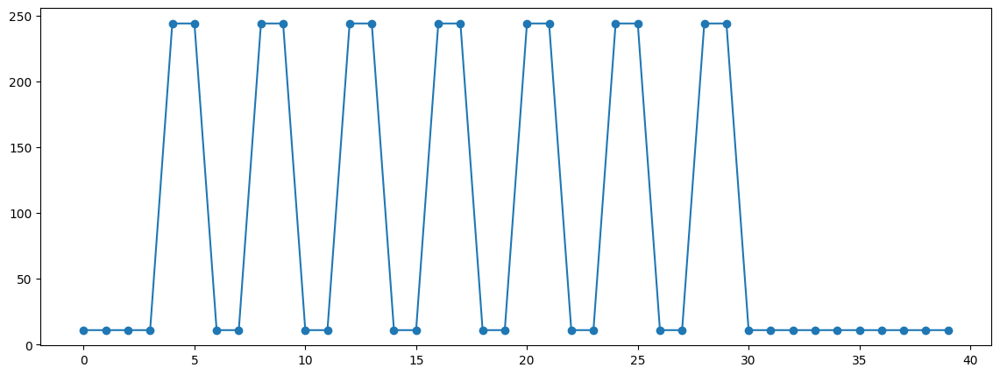

[128, 2208, 4288, 6368, 8448, 10528, 12608, 14687, 16767, 18848, 20927, 23007, 25087, 27167, 29247, 31327, 33407, 35487, 37567, 39647, 41727, 43807, 45887, 47967, 50047, 52127, 54207, 56287, 58367, 60447, 62527, 64607, 66687, 68767, 70846, 72926, 75006, 77086, 79166, 81246, 83326, 85406, 87486, 89566, 91646, 93726, 95806, 97886, 99966, 102046, 104126, 106206, 108286, 110366, 112446, 114526, 116605, 118682, 120766, 122845, 124925, 127005, 129085, 131165, 133245, 135325, 137405, 139485, 141569, 143645, 145725, 147805, 149885, 151965, 154045, 156125, 158205, 160285, 162365, 164445, 166525, 168605, 170685, 172769, 176925, 179004, 181085, 183164, 185244, 187324, 189404, 191484, 193564, 195644, 197724, 199804, 201884, 203964, 206044, 208124, 210204, 212284, 214363, 216444, 218524, 220604, 222684, 224764, 226844, 228924, 231004, 233083, 235164, 237243, 239323, 241403, 243483, 245563, 247643, 249723, 251803, 253883, 255967, 258039, 260123, 262203, 264283, 266363, 268443, 270523, 272603, 274683

In [ ]:
#obtener_muestras_comienzo_sync(rshapt,synca)

plt.figure(figsize=(14,5))
plt.plot(synca, 'o-')
plt.show()
print(obtener_muestras_comienzo_sync(apt,synca))


Compruebe el funcionamiento realizando las siguientes dos pruebas:

1) Graficar para alguno de los indices obtenidos, la señal APT centrada en ese indice $\pm$ 100 muestras. ¿Qué observa?

2) Calcule la diferencia entre un indice y el siguiente encontrado. ¿Cuanto es la diferencia? ¿Tiene sentido?

Repetir esto para algunos indices más.

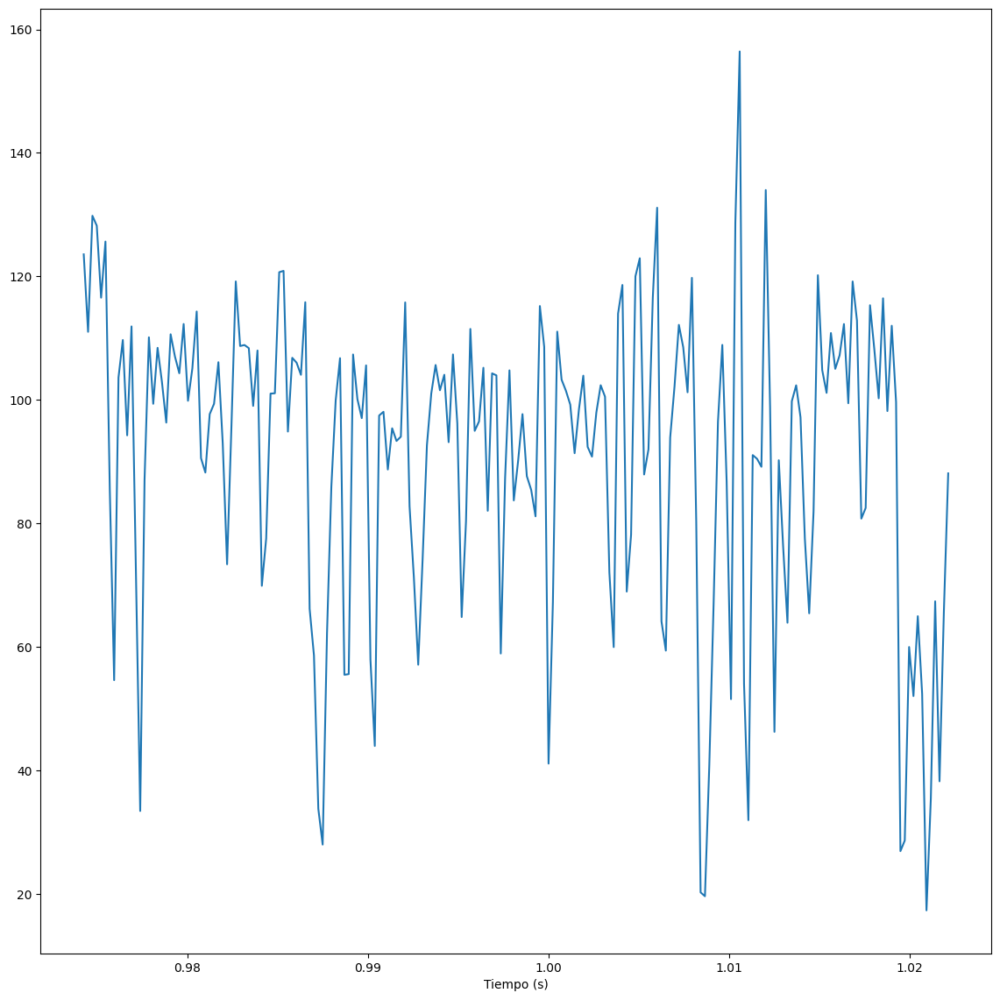

In [ ]:
plt.figure()
plt.plot(t[4153-100:4153+100],apt[4153-100:4153+100])
plt.xlabel('Tiempo (s)')
plt.savefig("grafica.png", dpi=150)
plt.show()

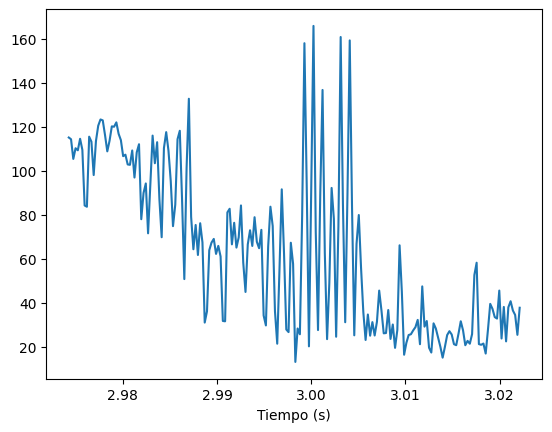

In [ ]:
plt.figure()
plt.plot(t[12473-100:12473+100],apt[12473-100:12473+100])
plt.xlabel('Tiempo (s)')
plt.savefig("grafica.png", dpi=150)
plt.show()

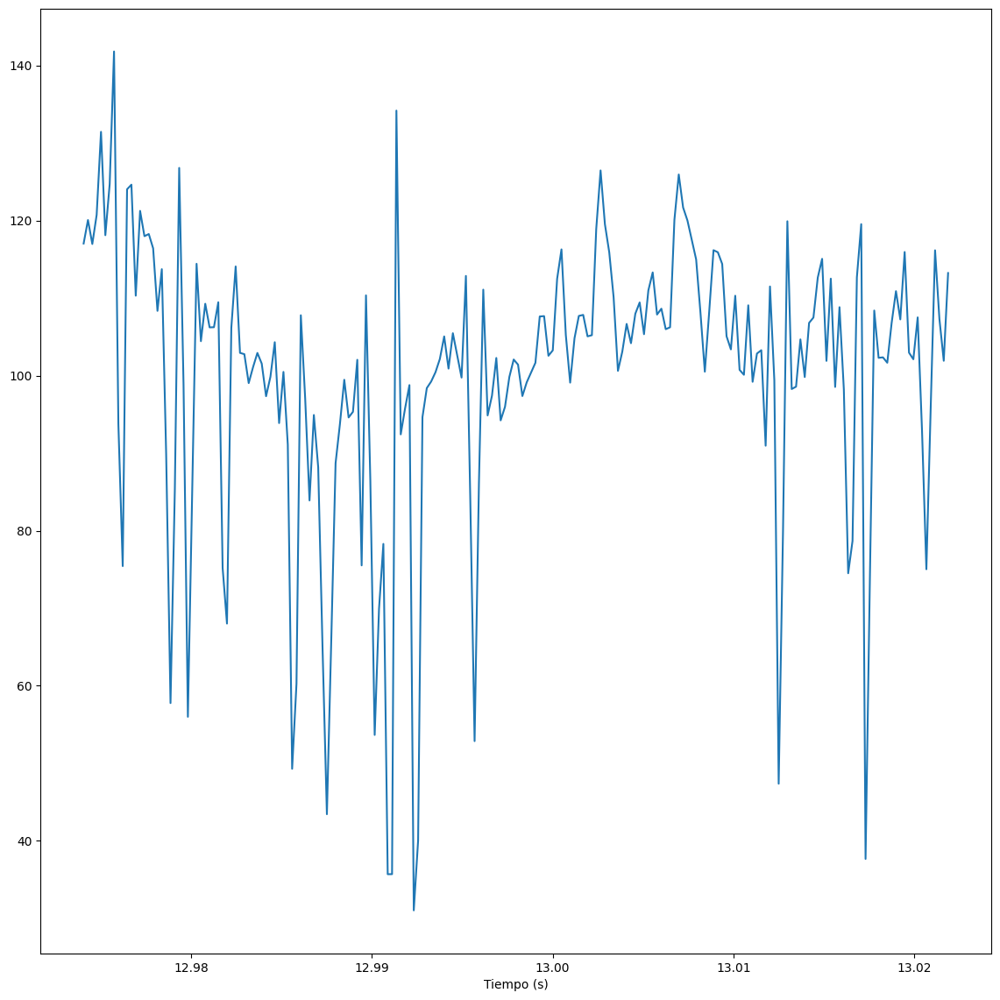

In [ ]:
plt.figure()
plt.plot(t[54072-100:54072+100],apt[54072-100:54072+100])
plt.xlabel('Tiempo (s)')
plt.savefig("grafica.png", dpi=150)
plt.show()

[2080. 2080. 2080. ... 3139. 2093.    0.]


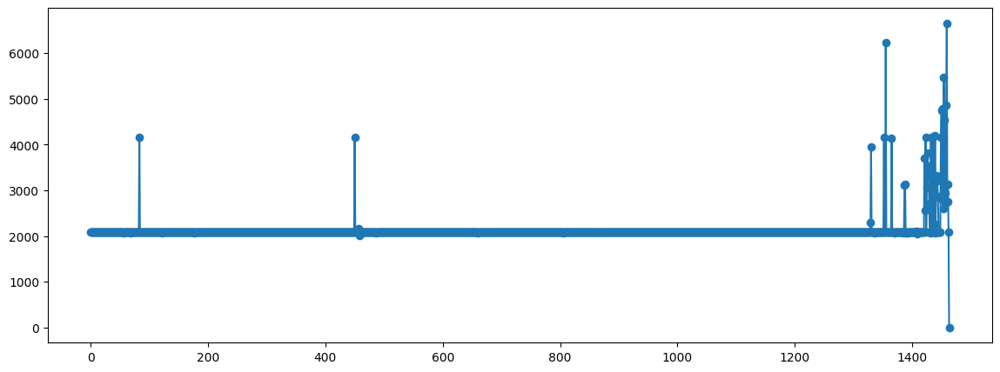

In [ ]:
#)Graficamos las diferencias para notar bien los saltos
dff=np.zeros(len(idx))
for k in range(len(idx)-1):
    dff[k]=np.abs(idx[k]-idx[k+1])
print(dff)

plt.figure(figsize=(14,5))
plt.plot(dff, 'o-')
plt.show()


Se observa que la diferencia entre indices es de aproximadamente 2080 muestras, lo cual concuerda con la composicion de las imagenes, ya que cada linea tiene 2080 pixeles/muestras. Se logran observar saltos en la grafica, estos se deben a ruido producido en el momento de la captura de la señal, el cual distorsiona los colores caracteristicos del sync, y por lo tanto la funcion para reconocerlo no lo hace.

### **Ejercicio 3**

Ahora que Ud. dispone de todos los indices de comienzo de cada linea de video APT, piense como podría utilizar esta información para armar una nueva imagen donde todas las lineas comienzan con el campo de sincronización. Implementelo y observe la imagen

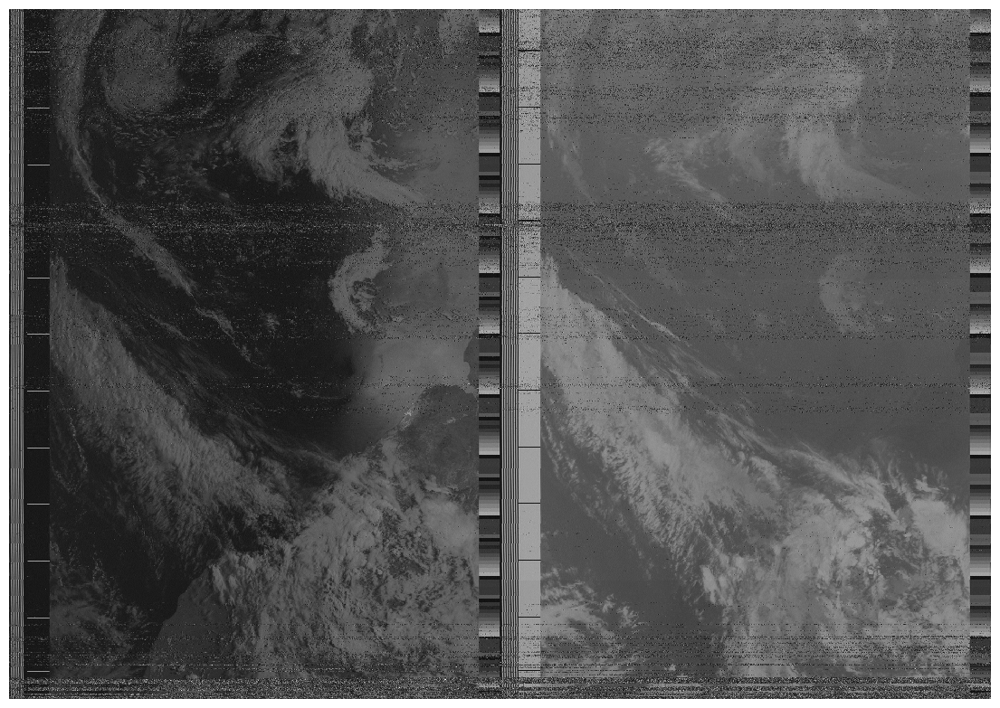

In [ ]:
aptsync=np.concatenate((apt[idx[0]:idx[0]+2080],apt[idx[1]:idx[1]+2080]))      #) Creamos una variable que concatene las 2 primeras lineas
for k in range(2,len(idx)-1):                                                  #) Creamos un bucle que recorra, sin contar las primeras dos lineas, el largo del indice menos el ultimo, ya que dicha linea no seria completa
  s=apt[idx[k]:idx[k]+2080]                                                    #) Creamos esta variable para que tome el valor del indice y sume 2080 muestras
  aptsync=np.concatenate((aptsync,s))                                          #) Concatenamos las variables reescribiendola en el proceso
rshsync= np.reshape(aptsync, (len(idx)-1, 2080))                               #) Obtenemos un vector 1d y aplicamos reshape para armar la matriz
visualizar_imagen(rshsync)


## PARTE 2: Telemetría

Si bien anteriormente normalizamos la señal para ocupar todo el rango 0-255, lo que puede suceder es que hayamos normalizado en una muestra con ruido. Esto se puede observar a partir del histograma de la señal APT. Grafique el histograma de la señal utilizando la función auxiliar correspondiente (se le debe pasar la señal en 1D).



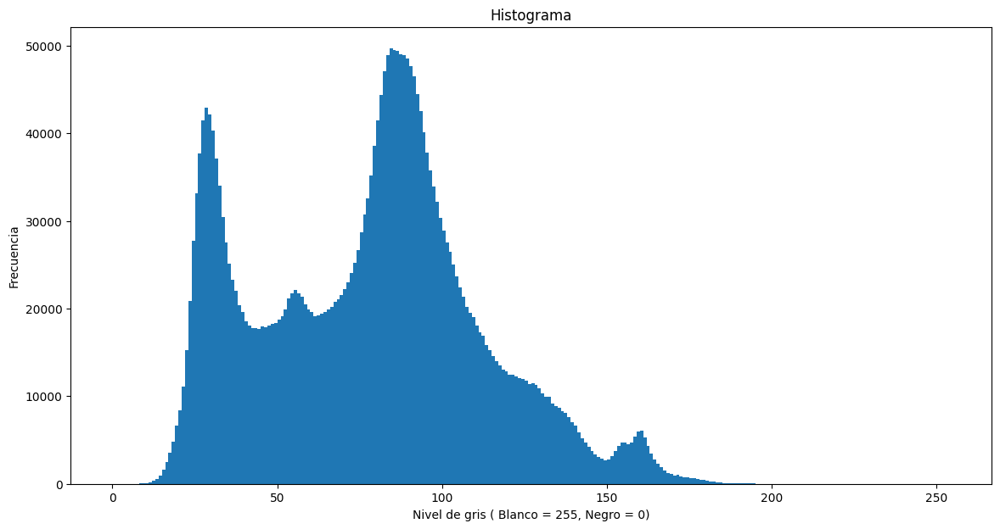

In [ ]:
visualizar_histograma(aptsync)


 Para solucionar esto, y recuperar los niveles del sensor AVHRR, la señal APT en el cuadro de telemetría envía valores conocidos para permitir una calibración. La siguiente tabla muestra como se compone el cuadro de telemetría y los valores de calibración, la cual **se compone de 16 "wedges"**. A su vez cada wedge **se repite en 8 filas y 45 columnas** consecutivas.


![texto alternativo](https://iie.fing.edu.uy/~gbelcredi/tallerineImSat/fig/wedges.png)

La idea de esta sección es obtener los valores que obtenemos nosotros en la telemetria, (que no van a coincidir con los valores reales de telemetria), y luego encontrar una transformación lineal (aX + b), que mejor transforme nuestros valores de telemetria, a los reales. El primer paso para esto es quedarnos únicamente con los pixeles correspondientes a la telemetría

### Ejercicio 4: Obtener Telemetria

De la imagen sincronizada, quedese solo con los pixeles de telemetria.  Visualizela utilizando la función visualizar_imagen.

*  ¿De que tamaño queda esta imagen?
*  ¿Cuantos cuadros completos de telemetria se  observan?




Se observan 11 cuadros de telemetria, 16x8x11 filas y 45 columnas

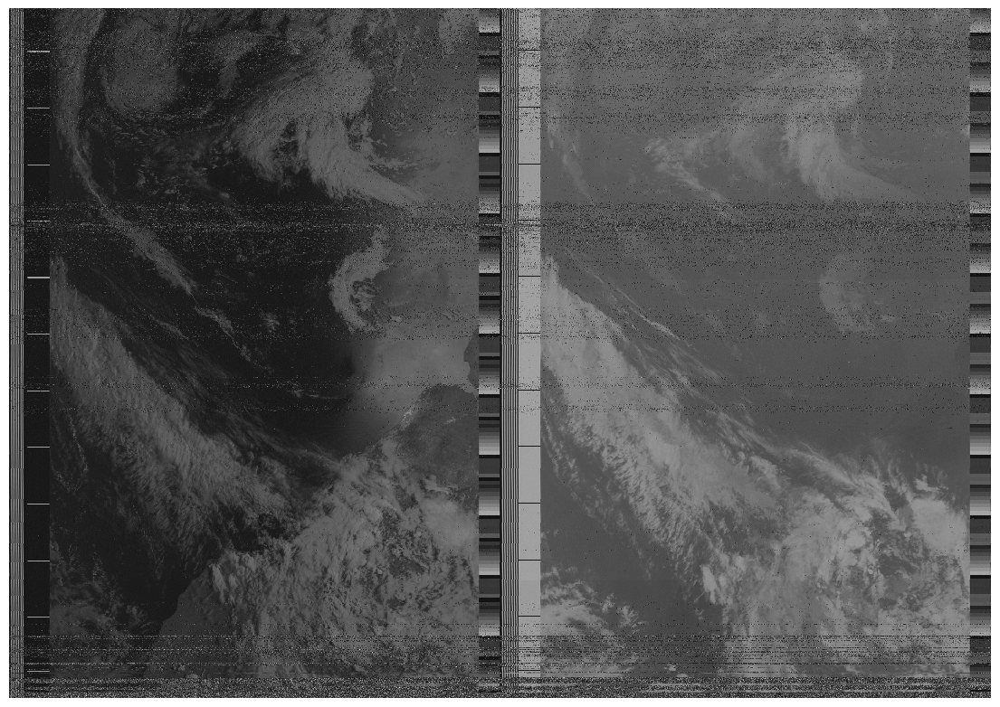

In [ ]:
visualizar_imagen(rshsync)

De todos los cuadros de telemetria, nos vamos a quedar unicamente con el menos ruidoso. Para esto, vamos a hacer un procedimiento parecido a lo que hicimos con el vector de sincronización. Utilizaremos correlación cruzada para encontrar donde comienza cada telemetria, y que tan similar es a la telemetria real. Aquella que presenta mayor similitud será la telemetria menos ruidosa. Sin embargo, para realizar la correlación cruzada, necesitamos una señal de 1D. Piense como podria pasara de tener 45 columnas de telemetría a tener 1 sola. Implementelo.

(1463, 45)
(1463,)


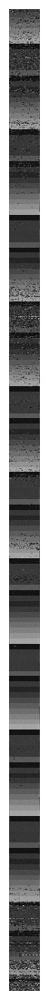

In [ ]:
telcol=rshsync[:,995:1040]           #) Tomamos el valor teorico de donde arranca y termina el telemetry y nos quedamos con toda esa columna-franja
print(telcol.shape)
visualizar_imagen(telcol)
prom=np.mean(telcol, 1)              #) Como necesitamos quedarnos con solo una columna, y para evitar errores en la lectura del telemetry gracias al ruido, hacemos un promedio de dichas columnas utilizando mean de numpy
print(prom.shape)
visualizar_imagen(prom)

Ahora tenemos una señal 1D con varios cuadros completos de telemetria. La siguiente función devuelve, a partir de esta señal, una lista con los indices donde comienza cada cuadro de telemetria, y otra lista con la similitud de cada cuadro con el cuadro real de telemetria.

In [ ]:
def obtener_indices_comienzo_telemetria_con_similitud(telemetry, sync_telemetry):
  # list of maximum correlations found: (index, value)
  peaks_corr = [(0, 0)]

  # minimum distance between peaks
  mindistance = 8*16 - 3

  # need to shift the values down to get meaningful correlation values
  signalshifted = [x-128 for x in telemetry]
  sync = [x-128 for x in sync_telemetry]

  for i in range(0,len(signalshifted) - len(sync)):

      corr = np.dot(sync, signalshifted[i : i+len(sync)])

      # if previous peak is too far, keep it and add this value to the
      # list as a new peak
      if i - peaks_corr[-1][0] > mindistance:
          peaks_corr.append((i, corr))

      # else if this value is bigger than the previous maximum, set this
      # one
      elif corr > peaks_corr[-1][1]:
          peaks_corr[-1] = (i, corr)

  peaks = [i[0] for i in peaks_corr] # retrieve peak indexes from peaks_corr
  corr = [i[1] for i in peaks_corr] # retrieve peak indexes from peaks_corr

  return peaks,corr

Defina el vector sync_telemetry y ejecute la función obtener_indices_comienzo_telemetria_con_similitud. Quedese con el cuadro de telemetria que mayor similitud presente.

In [ ]:
hh=[31,31,31,31,31,31,31,31,63,63,63,63,63,63,63,63,95,95,95,95,95,95,95,95,127,127,127,127,127,127,127,127,159,159,159,159,159,159,159,159,191,191,191,191,191,191,191,191,223,223,223,223,223,223,223,223,255,255,255,255,255,255,255,255,0,0,0,0,0,0,0,0,]                                                            #) Creamos el vector de sincronizacion del telemetry con los valores del digital value

In [ ]:
print(len(hh))

72


In [ ]:
idxtel, sim = obtener_indices_comienzo_telemetria_con_similitud(prom, hh)    #) Creamos dos variables que guarden la informacion requerica, indice y similitud

A partir de la información con la que cuenta arme un vector con los valores de calibración $[tel1,tel2,..,tel8,tel9]$ y compárelo en una misma gráfica con el patrón enviado por el satélite: $[31,63,95,127,159,191,223,255,0]$.

In [ ]:
print(idxtel)
print(sim)

print(np.max(sim))              #) Llamamos a la similitud mas grande con la funcion max de numpy

sim.index(np.max(sim))          #) Buscamos que lugar ocupa dentro del indice con la funcion index

[115, 243, 371, 498, 626, 754, 882, 1010, 1138, 1266]
[224401.96904166043, 265615.9457550651, 209481.23643755427, 249492.54847305288, 257285.53429622343, 260853.67645016607, 277843.92602264293, 277909.5236125759, 277705.1087853172, 233014.0034001352]
277909.5236125759


7

In [ ]:
nv=prom[idxtel[sim.index(np.max(sim))]:idxtel[sim.index(np.max(sim))] +72]
print(nv)
print(np.max(nv))
print(np.min(nv))

[ 37.1748032   37.36734807  37.00993544  37.02135343  37.29731572
  37.44149967  37.18772386  37.32998087  55.53025297  55.36412461
  55.02105752  55.19624559  55.25163491  55.34380087  54.92614411
  55.33611291  72.98477045  73.3083162   72.97942058  73.15366563
  73.70710762  73.3563467   73.31391887  73.22252476  91.62085491
  91.37114486  91.33207234  91.02642657  91.71620361  91.74517502
  90.95791631  91.17669527 108.65850605 108.70947959 108.99458368
 108.57690895 109.02812054 108.787926   108.78796908 108.4980882
 127.43206032 126.6719318  126.96791733 127.28372552 127.54118024
 127.71334182 127.3883521  127.18171942 145.65043039 145.34738136
 145.12904821 145.3825995  144.22114344 145.02340193 145.64919586
 145.70653349 163.42167867 164.31445035 163.74820262 163.81439071
 164.62262926 163.55399935 163.97450135 163.75787135  19.69622975
  20.69597046  20.18878861  20.15586246  20.08617686  20.05673284
  19.95970584  20.37618341]
164.62262925515813
19.696229750909385


### **Ejercicio 5: Calibración**
Para calibrar la imagen buscamos ahora una operación lineal de tipo $aX+ b \to Y$, que transforme el vector de calibración recibido en el vector de calibración original. Una vez obtenidos los valores de $a$ y $b$, aplique la transformación a todos los elementros de la matriz APT, es decir:

$\mathcal{I}_{apt~cal} = a\mathcal{I}_{apt} + b$

Visualice la imagen calibrada y grafique nuevamente el histograma, obtiene ahora lo que esperaba?

**Nota**: Para encontrar los coeficientes a y b averigue sobre la función polyfit de numpy: https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html

[ 63.73975477  42.21597615  25.41080559 ... 194.69279129  68.61512307
 182.31922863]


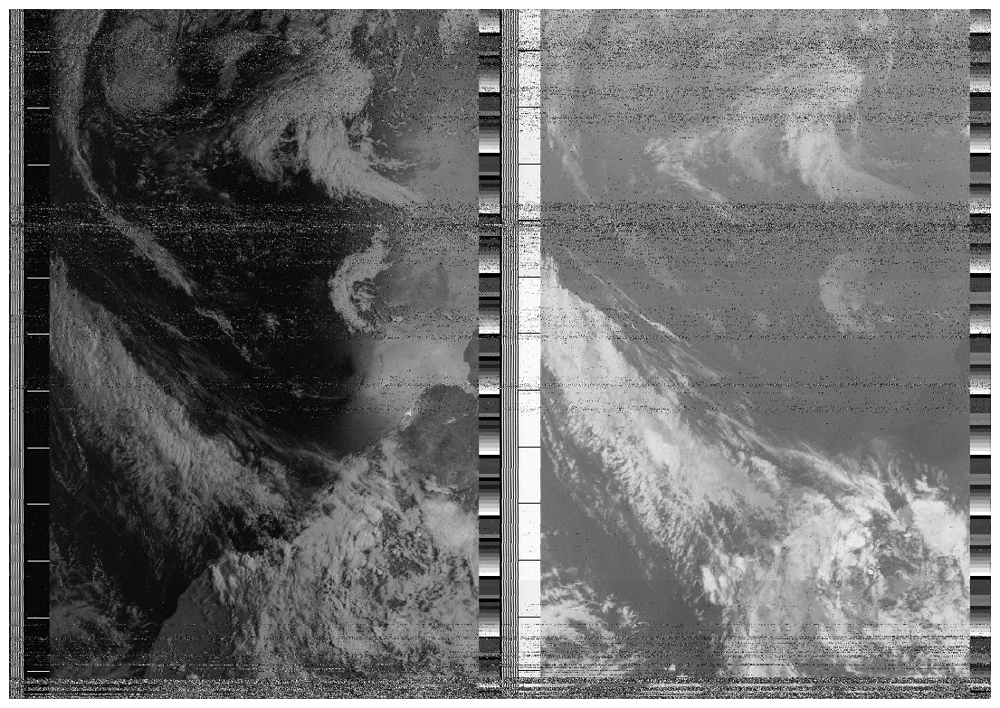

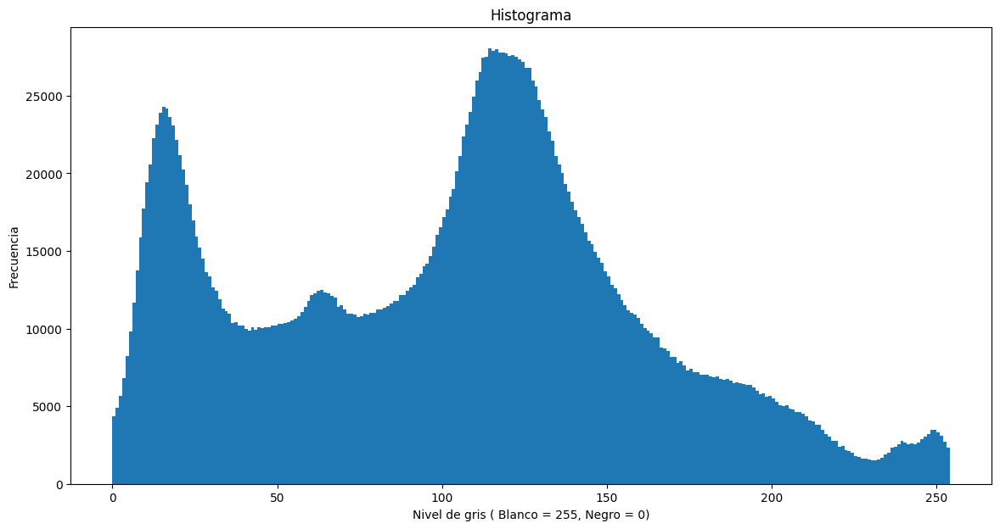

In [ ]:
a, b =np.polyfit(nv,hh,1)         #) Creo las variables a y b que reciben lo que nos da la funcion polyfit
aptcal=a*rshsync+b                #) Planteo la ecuacion proporcionada

visualizar_imagen(aptcal)
h=aptcal.flatten(order= 'C')
print(h)
visualizar_histograma(h)

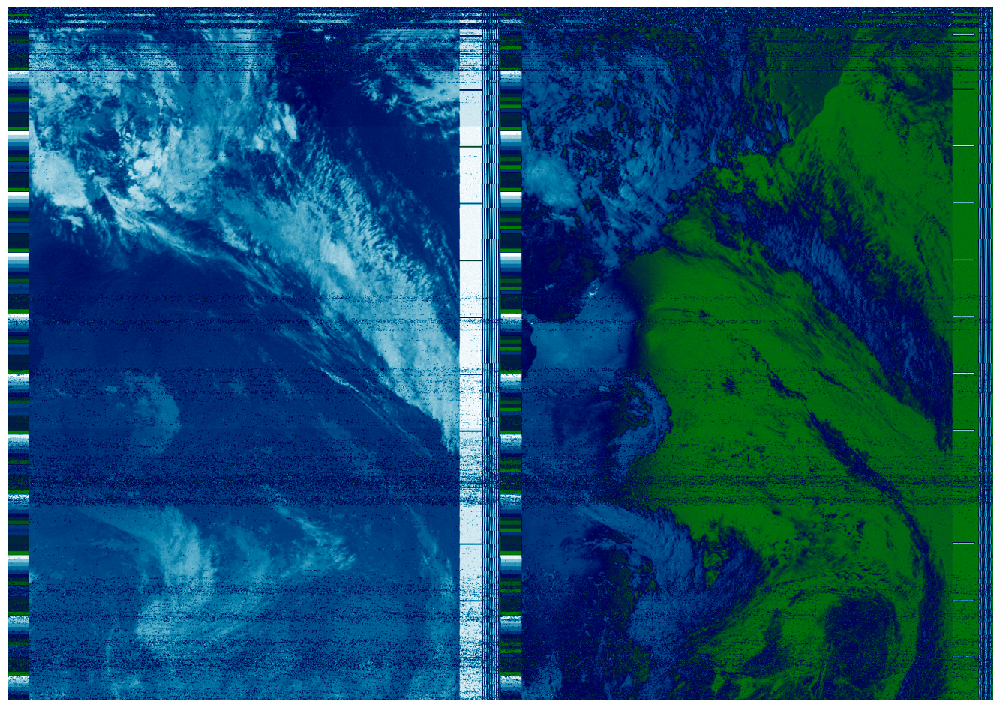

In [53]:
import matplotlib.image as mpimg

# Rotar la imagen
img_rotada = np.rot90(aptcal, k=2)           #) Rota la imagen 90 grados 2 veces(k=2) para obtener 180 grados

# Mostrar la imagen rotada
plt.figure(figsize=(28,12))
plt.axis('off')
plt.imshow(img_rotada,  cmap='ocean', interpolation='bilinear', vmin='0',vmax='255')  #) Utilizamos cmap, interpolation bilinear, y reafirmamos nuestra normalizacion
plt.show()


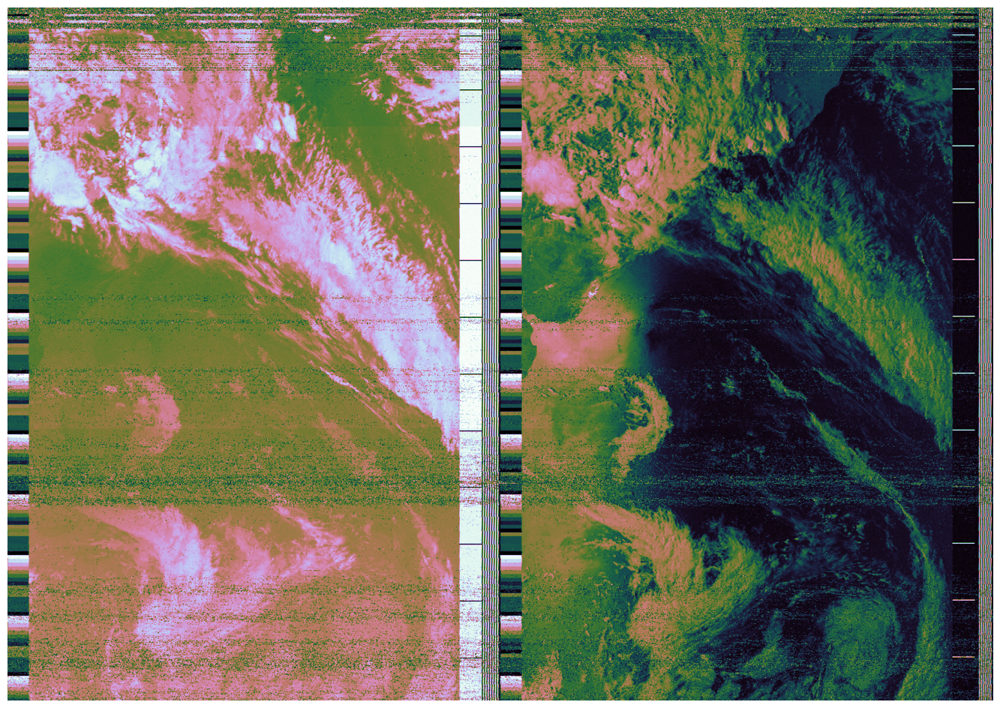

In [54]:
plt.figure(figsize=(28,12))
plt.axis('off')
plt.imshow(img_rotada,  cmap='cubehelix', interpolation='bilinear', vmin='0',vmax='255')  #) Utilizamos cmap, interpolation bilinear, y reafirmamos nuestra normalizacion
plt.show()

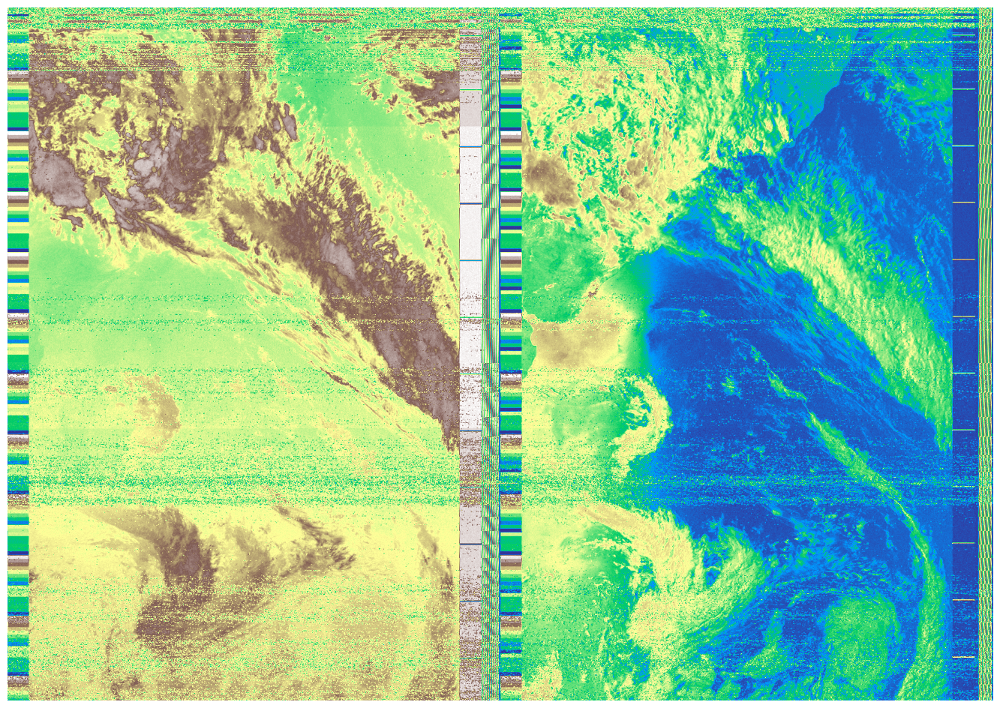

In [55]:
plt.figure(figsize=(28,12))
plt.axis('off')
plt.imshow(img_rotada,  cmap='terrain', interpolation='bilinear', vmin='0',vmax='255')  #) Utilizamos cmap, interpolation bilinear, y reafirmamos nuestra normalizacion
plt.show()

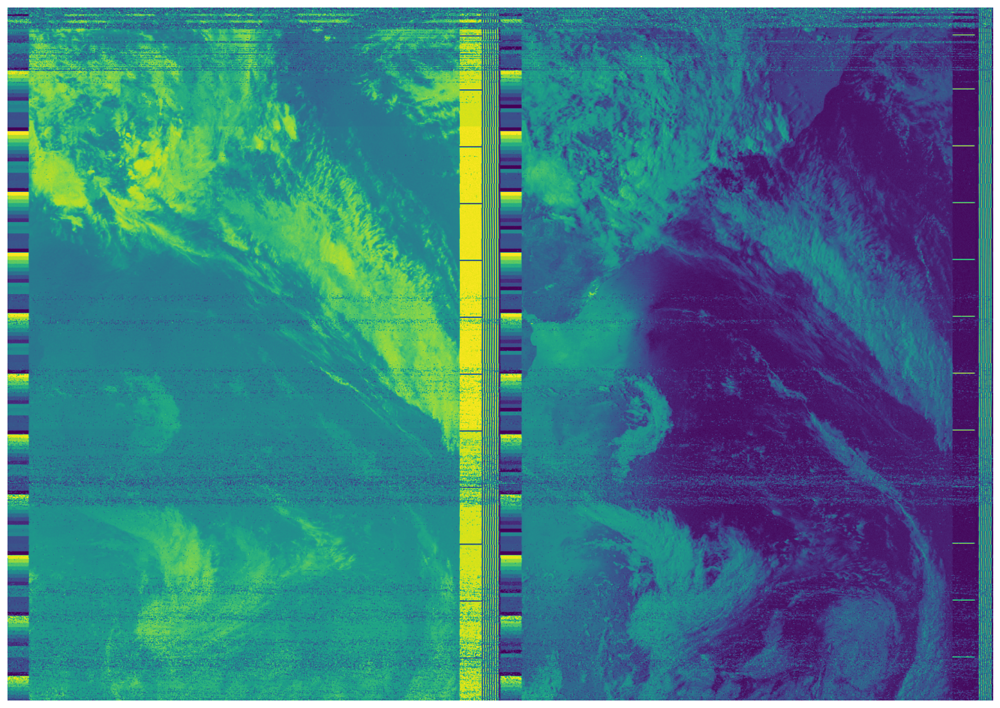

In [56]:
plt.figure(figsize=(28,12))
plt.axis('off')
plt.imshow(img_rotada,  cmap='viridis', interpolation='bilinear', vmin='0',vmax='255')  #) Utilizamos cmap, interpolation bilinear, y reafirmamos nuestra normalizacion
plt.show()

## Entregable

Deberá subir este notebook con los ejercicios resueltos, recuerde que puede agregar celdas de texto para acompañar el código y facilitar la comprensión.